In [13]:
import numpy as np
import matplotlib.pyplot as plt
from classy import Class
from matplotlib.ticker import LogLocator, NullFormatter

In [14]:
flag_savePlot = False

## SET MODEL

In [15]:
# ============================================================
# Helpers
# ============================================================

def run_classy(params, lmax=3000):
    cosmo = Class()
    cosmo.set(params)
    cosmo.compute()

    cl = cosmo.lensed_cl(lmax)
    bg = cosmo.get_background()

    derived = {}
    try:
        derived = cosmo.get_current_derived_parameters(
            ['H0', '100*theta_s', 'z_rec', 'tau_reio']
        )
    except Exception:
        pass

    cosmo.struct_cleanup()
    cosmo.empty()

    return cl, bg, derived


def Dl_TT_uK2_from_cl(cl, Tcmb=2.7255):
    """
    Convert CLASS tt spectrum to D_ell in microK^2.

    classy returns C_ell^{TT} for (Delta T / T)^2,
    so we must multiply by Tcmb^2 and by 1e12 to get microK^2.
    """
    ell = cl["ell"]
    Ctt = cl["tt"]  # dimensionless: (Delta T / T)^2
    Dl = ell * (ell + 1.0) * Ctt / (2.0 * np.pi)
    return ell, Dl * (Tcmb**2) * 1e12


In [16]:
# ============================================================
# Base cosmology: Bringmann-like reference setup
# ============================================================
# Here we use 100*theta_s directly instead of fixed h.
# This is the whole point of using this fork.
base = {
    '100*theta_s': 1.04077,
    'omega_b': 0.02225,
    'omega_cdm': 0.1198,
    'tau_reio': 0.0790,
    'ln10^{10}A_s': 3.094,
    'n_s': 0.9645,

    'output': 'tCl,mPk,lCl',
    'lensing': 'yes',
    'P_k_max_1/Mpc': 5.0,
    'l_max_scalars': 3000,
}

In [17]:
# ============================================================
# LCDM reference
# IMPORTANT: no DMDR parameters here
# ============================================================
cl_ref, bg_ref, drv_ref = run_classy(base, lmax=3000)
ell_ref, Dl_ref = Dl_TT_uK2_from_cl(cl_ref)
Ctt_ref = cl_ref["tt"]

print("Reference H0 =", drv_ref.get("H0", "n/a"))
print("Reference 100*theta_s =", drv_ref.get("100*theta_s", "n/a"))

Reference H0 = 67.45660167792967
Reference 100*theta_s = 1.0407695369424756


## ADD Monopoles

In [18]:
# ============================================================
# DMDR computation
# ============================================================
def compute_dmdr(
    f_dcdm,
    kappa_dcdm,
    a_t_dcdm,
    k_for_pk,
    fix_omch2_at_recombination=True,
    temperature_mode="full_lensed",
    lmax=3000,
    early_late_isw_redshift=50,
):
    """
    Compute TT spectrum + P(k) for the DM->DR model.

    temperature_mode options:
        - "full_lensed" : standard lensed TT
        - "full_raw"    : standard unlensed/raw TT
        - "tsw"         : ordinary Sachs-Wolfe only
        - "eisw"        : early ISW only
        - "lisw"        : late ISW only
        - "dop"         : Doppler only
        - "pol"         : polarization source contribution only
    """

    allowed_modes = {"full_lensed", "full_raw", "tsw", "eisw", "lisw", "dop", "pol"}
    if temperature_mode not in allowed_modes:
        raise ValueError(f"Unknown temperature_mode='{temperature_mode}'. Allowed: {sorted(allowed_modes)}")

    C = Class()
    settings = dict(base)

    settings_dmdr = {
        "f_mon": float(f_dcdm),
        "kappa_mon": float(kappa_dcdm),
        "a_t_mon": float(a_t_dcdm),
    }

    if fix_omch2_at_recombination:
        zcmb = 1100.0
        acmb = 1.0 / (1.0 + zcmb)
        omega_cdm_eff = settings["omega_cdm"] / (
            1.0 + f_dcdm * (1.0 - acmb**kappa_dcdm) / (1.0 + (acmb / a_t_dcdm)**kappa_dcdm)
        )
        settings_dmdr["omega_cdm"] = float(omega_cdm_eff)

    C.set(settings)
    C.set(settings_dmdr)

    # Source selection
    if temperature_mode in {"tsw", "eisw", "lisw", "dop", "pol"}:
        C.set({
            "lensing": "no",
            "temperature contributions": temperature_mode,
            "early_late_isw_redshift": early_late_isw_redshift,
        })
    elif temperature_mode == "full_raw":
        C.set({
            "lensing": "no",
        })
    elif temperature_mode == "full_lensed":
        C.set({
            "lensing": "yes",
        })

    C.compute()

    # Matter power spectrum
    pks_dmdr = np.array([C.pk(k, 0.0) for k in k_for_pk])

    # TT spectrum
    if temperature_mode == "full_lensed":
        cl_dmdr = C.lensed_cl(lmax)
    else:
        cl_dmdr = C.raw_cl(lmax)

    H0 = C.h() * 100.0
    S8 = C.sigma8() * np.sqrt(C.Omega_m() / 0.3)

    C.struct_cleanup()
    C.empty()

    return cl_dmdr, pks_dmdr, H0, S8


def compute_lcdm_reference(
    k_for_pk,
    temperature_mode="full_lensed",
    lmax=3000,
    early_late_isw_redshift=50,
):
    """
    Compute the LCDM reference spectrum with the same source selection
    as used for the DM->DR model.
    """

    allowed_modes = {"full_lensed", "full_raw", "tsw", "eisw", "lisw", "dop", "pol"}
    if temperature_mode not in allowed_modes:
        raise ValueError(f"Unknown temperature_mode='{temperature_mode}'. Allowed: {sorted(allowed_modes)}")

    C = Class()
    settings = dict(base)

    C.set(settings)

    if temperature_mode in {"tsw", "eisw", "lisw", "dop", "pol"}:
        C.set({
            "lensing": "no",
            "temperature contributions": temperature_mode,
            "early_late_isw_redshift": early_late_isw_redshift,
        })
    elif temperature_mode == "full_raw":
        C.set({
            "lensing": "no",
        })
    elif temperature_mode == "full_lensed":
        C.set({
            "lensing": "yes",
        })

    C.compute()

    pks_lcdm = np.array([C.pk(k, 0.0) for k in k_for_pk])

    if temperature_mode == "full_lensed":
        cl_lcdm = C.lensed_cl(lmax)
    else:
        cl_lcdm = C.raw_cl(lmax)

    H0_lcdm = C.h() * 100.0
    S8_lcdm = C.sigma8() * np.sqrt(C.Omega_m() / 0.3)

    C.struct_cleanup()
    C.empty()

    return cl_lcdm, pks_lcdm, H0_lcdm, S8_lcdm

In [19]:
# ============================================================
# LCDM reference P(k), H0, S8
# ============================================================
k_for_pk = np.logspace(-3, np.log10(3.0), 300)

C0 = Class()
C0.set(base)
C0.compute()

Pk_lcdm = np.array([C0.pk(k, 0.0) for k in k_for_pk])
CLtt_lcdm = C0.lensed_cl(3000)
H0_lcdm = C0.h() * 100.0
S8_lcdm = C0.sigma8() * np.sqrt(C0.Omega_m() / 0.3)

C0.struct_cleanup()
C0.empty()

print("LCDM H0 =", H0_lcdm)
print("LCDM S8 =", S8_lcdm)

LCDM H0 = 67.45660167792967
LCDM S8 = 0.8605398293294723


## CMB SPECTRA PLOT

In [20]:
# tsw - Ordinary Sachs–Wolfe
# eisw - Early Integrated Sachs–Wolfe
# lisw - Late Integrated Sachs–Wolfe
# dop - Doppler
# pol - Polarization source
# full_lensed - full
temperature_mode = "full_lensed"

CLtt_lcdm, Pk_lcdm, H0_lcdm, S8_lcdm = compute_lcdm_reference(
    k_for_pk=k_for_pk,
    temperature_mode=temperature_mode,
    lmax=3000,
)

cases = [
    (1/(40+1), 0.05),
    # (0.089303, 0.05),
]

kappas = [100, 7.3077]

models = []

for kappa in kappas:
    for a_t, f in cases:
        CLtt_dmdr, pk_dmdr, H0_dmdr, S8_dmdr = compute_dmdr(
            f_dcdm=f,
            kappa_dcdm=kappa,
            a_t_dcdm=a_t,
            k_for_pk=k_for_pk,
            fix_omch2_at_recombination=True,
            temperature_mode=temperature_mode,
            lmax=3000,
        )

        models.append({
            "kappa": kappa,
            "a_t": a_t,
            "f": f,
            "cl": CLtt_dmdr,
            "pk": pk_dmdr,
            "H0": H0_dmdr,
            "S8": S8_dmdr,
        })

        print(f"kappa={kappa}, a_t={a_t:.0e}, f={f}: H0={H0_dmdr:.3f}, S8={S8_dmdr:.4f}")

kappa=100, a_t=2e-02, f=0.05: H0=71.189, S8=0.7883
kappa=7.3077, a_t=2e-02, f=0.05: H0=71.176, S8=0.7884


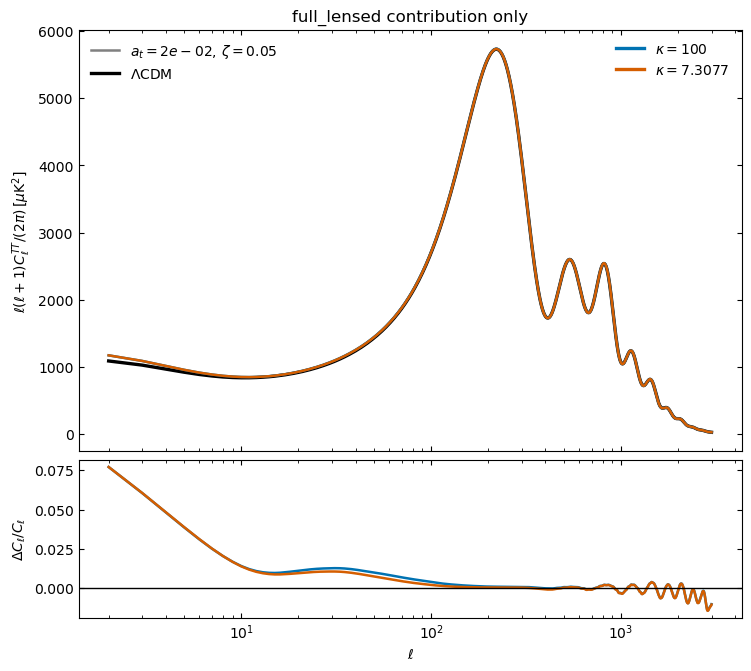

In [21]:
ell_ref, Dl_ref = Dl_TT_uK2_from_cl(CLtt_lcdm)

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(7.4, 6.6),
    sharex=True,
    gridspec_kw={"height_ratios": [3.2, 1.2]},
    constrained_layout=True
)

ell_plot_min = 2

# -------------------------------------------------
# Color-blind safe colors for kappa
# -------------------------------------------------

kappa_colors = [
    "#0072B2",  # blue
    "#D55E00",  # vermillion
    "#009E73",  # bluish green
    "#CC79A7",  # purple
]

color_map = {k: kappa_colors[i] for i, k in enumerate(kappas)}

# -------------------------------------------------
# Linestyles for transition redshift
# -------------------------------------------------

linestyles = ['-', '--', '-.', ':']
style_map = {case: dict(ls=linestyles[i], lw=1.8) for i, case in enumerate(cases)}

# -------------------------------------------------
# Top panel
# -------------------------------------------------

ax1.plot(
    ell_ref[ell_plot_min:], Dl_ref[ell_plot_min:],
    color='black', lw=2.4, label=r'$\Lambda$CDM'
)

for m in models:

    ell, Dl = Dl_TT_uK2_from_cl(m["cl"])
    style = style_map[(m["a_t"], m["f"])]

    ax1.plot(
        ell[ell_plot_min:], Dl[ell_plot_min:],
        color=color_map[m["kappa"]],
        **style
    )

ax1.set_ylabel(r"$\ell(\ell+1)C_\ell^{TT}/(2\pi)\,[\mu{\rm K}^2]$")
ax1.set_title(rf"{temperature_mode} contribution only")

ax1.set_xscale("log")
ax1.tick_params(which="both", direction="in", top=True, right=True)

# -------------------------------------------------
# Bottom panel
# -------------------------------------------------

ell_ref_arr = CLtt_lcdm["ell"]
Ctt_ref_arr = CLtt_lcdm["tt"]

eps = 1e-40 if temperature_mode in {"tsw","eisw","lisw","dop","pol"} else 1e-30

for m in models:

    ell = m["cl"]["ell"]
    Ctt = m["cl"]["tt"]

    if not np.array_equal(ell, ell_ref_arr):
        Ctt = np.interp(ell_ref_arr, ell, Ctt)
        ell = ell_ref_arr

    valid = (
        np.isfinite(Ctt_ref_arr)
        & np.isfinite(Ctt)
        & (np.abs(Ctt_ref_arr) > eps)
        & (ell >= ell_plot_min)
    )

    frac = np.full_like(Ctt_ref_arr, np.nan)
    frac[valid] = (Ctt[valid] - Ctt_ref_arr[valid]) / Ctt_ref_arr[valid]

    style = style_map[(m["a_t"], m["f"])]

    ax2.plot(
        ell[valid], frac[valid],
        color=color_map[m["kappa"]],
        **style
    )

ax2.axhline(0, color="black", lw=1)

ax2.set_ylabel(r"$\Delta C_\ell/C_\ell$")
ax2.set_xlabel(r"$\ell$")

ax2.set_xscale("log")

# For: "lisw"
# ax2.set_yscale("log")
# ax2.set_ylim(1e-1, 1e3)

ax2.tick_params(which="both", direction="in", top=True, right=True)

# -------------------------------------------------
# Legends
# -------------------------------------------------

from matplotlib.lines import Line2D

# linestyle legend (a_t)
legend_lines_cases = [
    Line2D([0],[0],color='grey',lw=1.8,ls=linestyles[i],
           label=fr"$a_t={cases[i][0]:.0e},\,\zeta={cases[i][1]}$")
    for i in range(len(cases))
]

# color legend (kappa)
legend_lines_kappa = [
    Line2D([0],[0],color=color_map[k],lw=2.4,
           label=fr"$\kappa={k}$")
    for k in kappas
]

legend_lcdm = [
    Line2D([0],[0],color='black',lw=2.4,label=r"$\Lambda$CDM")
]

# first legend
leg1 = ax1.legend(
    handles=legend_lines_cases + legend_lcdm,
    frameon=False,
    fontsize=10,
    loc="upper left"
    # loc="upper center"

)

# second legend
leg2 = ax1.legend(
    handles=legend_lines_kappa,
    frameon=False,
    fontsize=10,
    loc="upper right"
)

ax1.add_artist(leg1)

# -------------------------------------------------
if flag_savePlot:
    plt.savefig(f"{temperature_mode}_contribution.pdf")
else:
    plt.show()

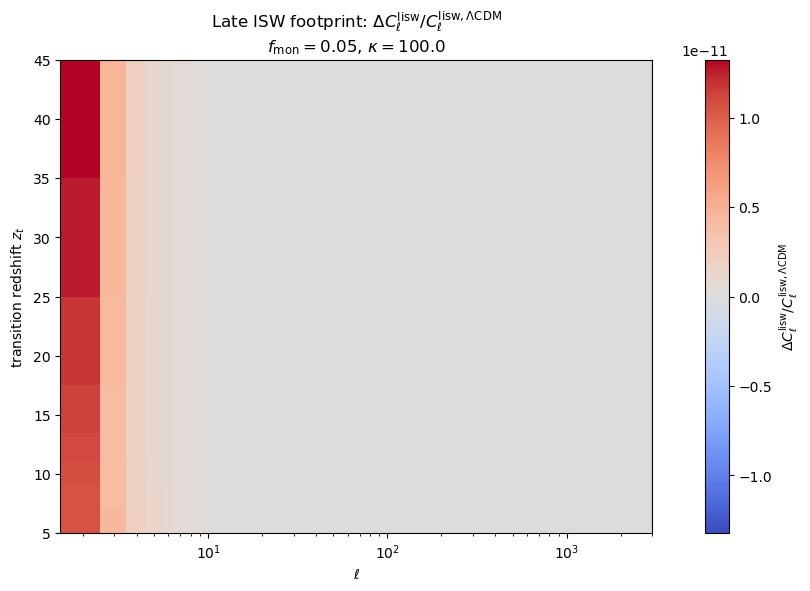

In [27]:
# ============================================================
# DIRECT ISW FOOTPRINT MAP
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

def z_to_a(z):
    return 1.0 / (1.0 + z)

def safe_ratio(num, den, eps=1e-30):
    out = np.zeros_like(num)
    mask = np.abs(den) > eps
    out[mask] = num[mask] / den[mask]
    return out

# -----------------------------
# User choices
# -----------------------------
f_mon_fixed = 0.05
kappa_fixed = 100.0          # use a sharp case first
z_transition_list = [6, 8, 10, 12, 15, 20, 30, 40]
lmax_plot = 3000
ell_min_plot = 2

temperature_mode = "lisw"    # isolate late ISW only

# -----------------------------
# LCDM reference (lisw only)
# -----------------------------
cl_lcdm_lisw, _, _, _ = compute_lcdm_reference(
    k_for_pk=k_for_pk,
    temperature_mode=temperature_mode,
    lmax=lmax_plot,
)

ell_ref = cl_lcdm_lisw["ell"]
Cl_ref = cl_lcdm_lisw["tt"]

# -----------------------------
# Scan z_t
# -----------------------------
ratio_rows = []
all_cls = []

for zt in z_transition_list:
    a_t = z_to_a(zt)

    cl_mono, _, H0_mono, S8_mono = compute_dmdr(
        f_dcdm=f_mon_fixed,
        kappa_dcdm=kappa_fixed,
        a_t_dcdm=a_t,
        k_for_pk=k_for_pk,
        fix_omch2_at_recombination=True,
        temperature_mode=temperature_mode,
        lmax=lmax_plot,
    )

    Cl_mono = cl_mono["tt"]
    frac = abs(Cl_mono - Cl_ref)
    # frac = safe_ratio(Cl_mono - Cl_ref, Cl_ref)

    ratio_rows.append(frac)
    all_cls.append({
        "z_t": zt,
        "a_t": a_t,
        "cl": cl_mono,
        "frac": frac,
        "H0": H0_mono,
        "S8": S8_mono,
    })

ratio_map = np.array(ratio_rows)

# ============================================================
# PLOT 1: 2D map of fractional lisw change
# ============================================================
fig, ax = plt.subplots(figsize=(8.0, 5.8), constrained_layout=True)

# avoid ell=0,1
ell = ell_ref[ell_min_plot:]
ratio_map_plot = ratio_map[:, ell_min_plot:]

# symmetric color scaling around 0
vmax = np.max(np.abs(ratio_map_plot))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

im = ax.pcolormesh(
    ell,
    z_transition_list,
    ratio_map_plot,
    shading="auto",
    cmap="coolwarm",
    norm=norm
)

ax.set_xscale("log")
ax.set_xlabel(r"$\ell$")
ax.set_ylabel(r"transition redshift $z_t$")
ax.set_title(
    rf"Late ISW footprint: $\Delta C_\ell^{{\rm lisw}} / C_\ell^{{\rm lisw,\Lambda CDM}}$"
    "\n"
    rf"$f_{{\rm mon}}={f_mon_fixed}$, $\kappa={kappa_fixed}$"
)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r"$\Delta C_\ell^{\rm lisw} / C_\ell^{\rm lisw,\Lambda CDM}$")

plt.show()

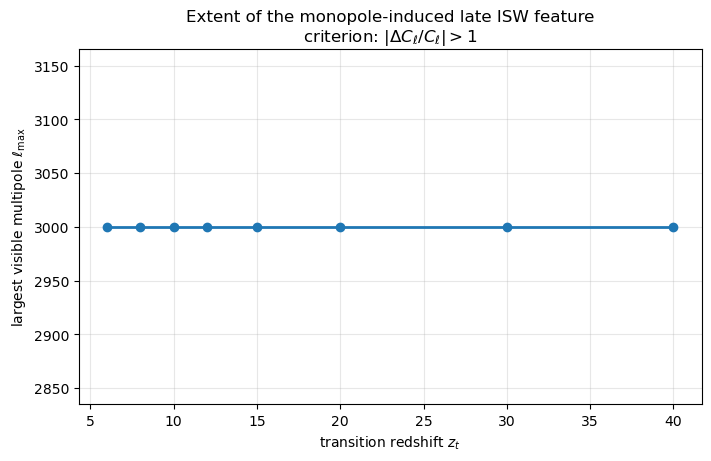

In [23]:
# ============================================================
# PLOT 2: characteristic visible ell-range
# ============================================================
threshold = 0.01   # 1% fractional deviation
ell_visible_max = []

for row in ratio_map:
    frac_abs = np.abs(row)
    idx = np.where(frac_abs[ell_min_plot:] > threshold)[0]

    if len(idx) == 0:
        ell_visible_max.append(np.nan)
    else:
        ell_visible_max.append(ell_ref[ell_min_plot:][idx[-1]])

fig, ax = plt.subplots(figsize=(7.0, 4.5), constrained_layout=True)

ax.plot(z_transition_list, ell_visible_max, marker="o", lw=2)

ax.set_xlabel(r"transition redshift $z_t$")
ax.set_ylabel(r"largest visible multipole $\ell_{\rm max}$")
ax.set_title(
    rf"Extent of the monopole-induced late ISW feature"
    "\n"
    rf"criterion: $|\Delta C_\ell/C_\ell| > {threshold:.0%}$"
)

ax.grid(alpha=0.3)
plt.show()

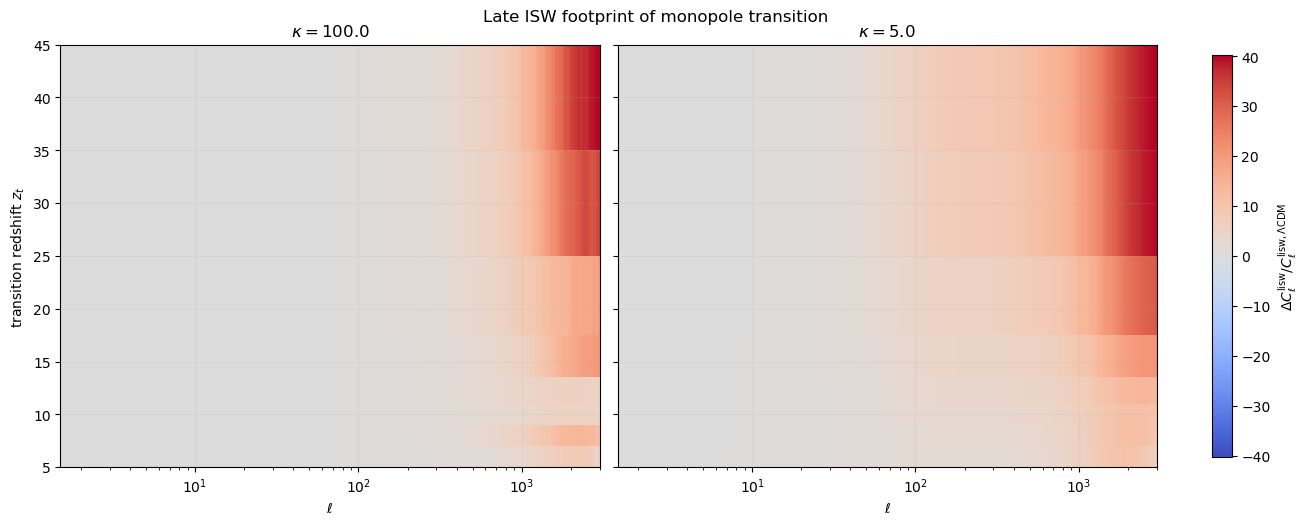

In [26]:
# ============================================================
# PLOT 3: compare sharpness directly
# ============================================================
kappa_list_compare = [100.0, 5.0]
fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.0), sharey=True, constrained_layout=True)

for ax, kappa_now in zip(axes, kappa_list_compare):
    ratio_rows = []

    for zt in z_transition_list:
        a_t = z_to_a(zt)

        cl_mono, _, _, _ = compute_dmdr(
            f_dcdm=f_mon_fixed,
            kappa_dcdm=kappa_now,
            a_t_dcdm=a_t,
            k_for_pk=k_for_pk,
            fix_omch2_at_recombination=True,
            temperature_mode="lisw",
            lmax=lmax_plot,
        )

        Cl_mono = cl_mono["tt"]
        frac = safe_ratio(Cl_mono - Cl_ref, Cl_ref)
        ratio_rows.append(frac)

    ratio_map_now = np.array(ratio_rows)[:, ell_min_plot:]
    vmax = np.max(np.abs(ratio_map_now))
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    im = ax.pcolormesh(
        ell_ref[ell_min_plot:],
        z_transition_list,
        ratio_map_now,
        shading="auto",
        cmap="coolwarm",
        norm=norm
    )

    ax.set_xscale("log")
    ax.set_xlabel(r"$\ell$")
    ax.set_title(rf"$\kappa={kappa_now}$")
    ax.grid(alpha=0.15)

axes[0].set_ylabel(r"transition redshift $z_t$")
fig.suptitle(r"Late ISW footprint of monopole transition", y=1.02)

cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.95)
cbar.set_label(r"$\Delta C_\ell^{\rm lisw}/C_\ell^{\rm lisw,\Lambda CDM}$")

plt.show()